<a href="https://colab.research.google.com/github/Thilak-K21/ML-LAB/blob/main/1WA23CS021_ML_LAB_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A support vector machine is a powerful supervised machine learning algorithm used for both classification and regression. It works by finding th most optimal hyperplane which is a decision boundary that seperates data points of different classes with the widest possible distances.It is called as margin.

Core Concepts of Support Vector machines:
* **Hyperplane** :  A boundary that seperates the data space. In 2D it is a line and in 3D it is a plane.
* **Support Vectors**: These are the data points located closest to the hyperplane.They are the only points and orientation of the decision boundary.
* **Margin** : The gap between the hyperplane and the nearest support vectors from each class. SVM aims to maximize this margin to improve the model's ability to generalize to new, unseen data.
* **Kernel Trick** : When data is not linearly separable (cannot be split by a straight line), SVM uses a "kernel" function to map the data into a higher-dimensional space where a linear separator can be found. [1, 2, 3, 4, 5]



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv('iris.csv')

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 1.0


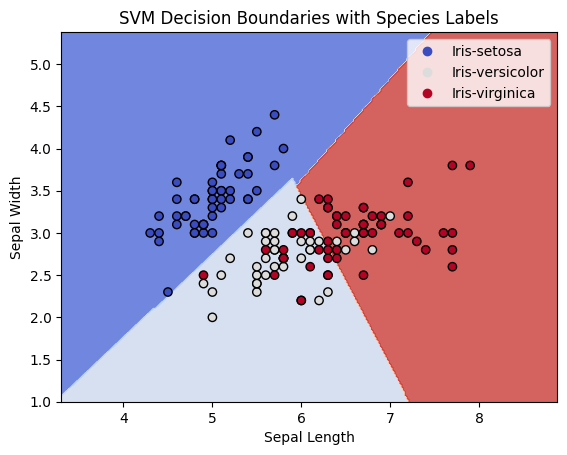

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

df = pd.read_csv('iris.csv')
X = df.iloc[:, :2].values
y, species_names = pd.factorize(df['species'])

model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)

h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

plt.legend(handles=scatter.legend_elements()[0], labels=list(species_names))

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('SVM Decision Boundaries with Species Labels')
plt.show()


**1. Support Vector Margins & Decision Boundary**

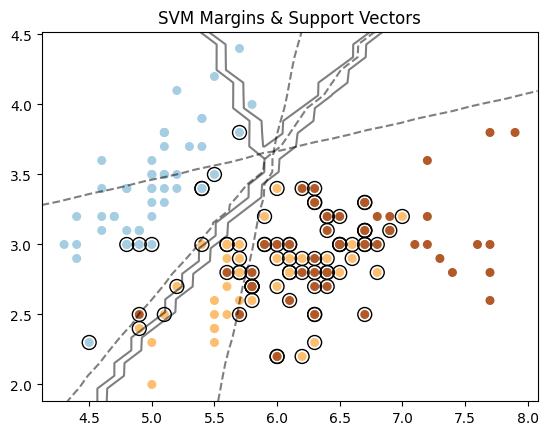

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

df = pd.read_csv('iris.csv')
X = df.iloc[:, :2].values
y, _ = pd.factorize(df['species'])

model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

P = model.decision_function(xy)
for i in range(P.shape[1]):
    ax.contour(XX, YY, P[:, i].reshape(XX.shape), colors='k',
               levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')
plt.title("SVM Margins & Support Vectors")
plt.show()


**2. Hyperparameter Heatmap (C vs. Gamma)**

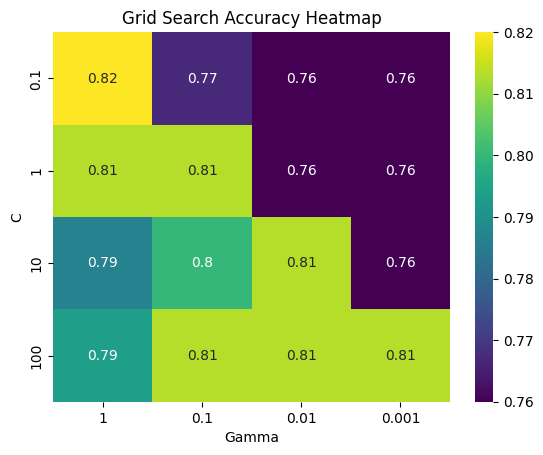

In [9]:
import seaborn as sns
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']}
grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=0)
grid.fit(X, y)

scores = grid.cv_results_['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['gamma']))

sns.heatmap(scores, annot=True, xticklabels=param_grid['gamma'], yticklabels=param_grid['C'], cmap='viridis')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.title('Grid Search Accuracy Heatmap')
plt.show()


**3. Confusion Matrix**

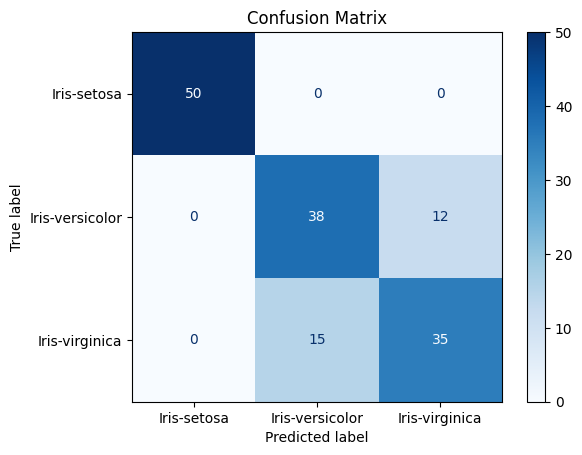

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df['species'].unique())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
